# Day 15: Predicting Customer Churn with Logistic Regression

Welcome to Day 15 of my **60-Day Data Science Challenge**! 🚀
Today marks the beginning of the **Classification Foundations** phase. After spending the past few days building regression pipelines to predict continuous sales values, we are shifting focus to predicting categorical binary outcomes.

## Real-World Impact
Subscription-based businesses (like telecom providers, streaming services, or SaaS companies) live and die by customer retention. Predicting **churn**—whether a customer will leave the service—allows businesses to target at-risk customers with proactive retention campaigns (like discounts or customized support) before they cancel, saving millions of dollars in lost revenue.

## Today's Learning Objectives:
1. **Load and Explore a Churn Dataset**: Use the public IBM Telco Customer Churn dataset.
2. **Identify Target & Feature Columns**: Separate our categorical target (`Churn`) from numeric and categorical features.
3. **Clean Messy Real-World Data**: Fix a common data-typing issue with the `TotalCharges` feature.
4. **Preprocess and Encode Data**: Prepare categorical features via One-Hot Encoding and scale continuous numerical features.
5. **Prevent Data Leakage**: Split data into train and test sets using **stratification** before applying scaling transformations.
6. **Train a Logistic Regression Classifier**: Teach our baseline model how to classify churn.
7. **Analyze Prediction Diagnostics**: Generate a Confusion Matrix, ROC-AUC curve, and extract model coefficients.
8. **Document Business Implications**: Reflect on the real-world cost differences between False Positives and False Negatives.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Setting style for modern, student-made visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 11

### 1. Load the Dataset & Exploratory Inspection

We will read the dataset from our local directory (which was fetched from the public IBM repository). Let's load the data and check its structure, dimensions, and columns.

In [2]:
# Ingest the customer churn dataset
df = pd.read_csv('telco_customer_churn.csv')
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")

# Check column types and non-null values
df.info()

Dataset shape: 7043 rows, 21 columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pap

Let's print the first three rows to see the column representations.

In [3]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


### 2. Data Cleaning & Handling Missing Values

During my inspection, I noticed that `TotalCharges` is of type `object` (string) rather than `float64`, even though it represents numerical currency values. This is a common real-world data science cleaning problem!
Let's see why it was read as a string. Are there empty strings or white spaces?

In [4]:
# Find rows where TotalCharges is just empty spaces
blank_rows = df[df['TotalCharges'].str.strip() == '']
print(f"Found {len(blank_rows)} rows with empty/blank 'TotalCharges' values.")
blank_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head()

Found 11 rows with empty/blank 'TotalCharges' values.


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,


**Student Observation:** Ah! All these blank rows have a `tenure` of `0`. This means they are brand new customers who have just signed up and haven't completed their first billing cycle yet, so their total billed charges are technically $0.00.

Let's clean this by replacing the empty spaces with `NaN`, converting the column to float, and then filling the missing values with `0.0`.

In [5]:
# Replace empty spaces with NaN and convert to float
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Fill NaNs with 0.0
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Verify the conversion
print(f"New missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"TotalCharges type: {df['TotalCharges'].dtype}")

New missing values in TotalCharges: 0


TotalCharges type: float64


### 3. Preprocessing: Encoding Target and Features

Next, we prepare our data for machine learning modeling:
1. **Encode Target Variable**: Map our `Churn` column from String (`Yes` / `No`) to Binary (`1` / `0`).
2. **Leakage Prevention**: Exclude `customerID` as it's a unique identifier that contains no physical predictive signals.
3. **Categorical Feature Encoding**: One-Hot Encode our categorical features. We use `drop_first=True` to prevent the **dummy variable trap** (perfect multi-collinearity), which is critical for standard linear models like Logistic Regression.

In [6]:
# Map target column
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"Target class distribution:\n{df['Churn'].value_counts(normalize=True)}")

# Separate Target and Features, dropping customerID
target_col = 'Churn'
features_df = df.drop(columns=['customerID', target_col])

# Identify numerical and categorical features
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in features_df.columns if col not in numerical_cols]

# One-Hot Encode categorical variables
df_encoded = pd.get_dummies(features_df, columns=categorical_cols, drop_first=True)
print(f"\nEncoded dataframe shape: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns.")

Target class distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Encoded dataframe shape: 7043 rows, 30 columns.


### 4. Stratified Train-Test Split

We split our data into an **80% training set** (to teach our model patterns) and a **20% test set** (to evaluate its performance on unseen data).

Since our target column `Churn` is imbalanced (~26.5% churn, ~73.5% stay), we apply `stratify=y` inside `train_test_split`. This guarantees that both the training and test partitions receive the exact same proportion of churned vs. retained customers, preventing biased splits.

In [7]:
X = df_encoded
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training partition dimensions: {X_train.shape[0]} rows, {X_train.shape[1]} features.")
print(f"Testing partition dimensions:  {X_test.shape[0]} rows, {X_test.shape[1]} features.")
print(f"Train Churn Ratio: {y_train.mean():.4%}")
print(f"Test Churn Ratio:  {y_test.mean():.4%}")

Training partition dimensions: 5634 rows, 30 features.
Testing partition dimensions:  1409 rows, 30 features.
Train Churn Ratio: 26.5353%
Test Churn Ratio:  26.5436%


### 5. Standard Scaling with Leakage Prevention

Logistic Regression models perform best when numerical features are scaled. 
**Critical Leakage Warning ⚠️:** We must **fit** the standard scaler **only** on the training set to prevent test data statistics from leaking into our features. Then, we **transform** both the training and testing features.

In [8]:
scaler = StandardScaler()

# Create copies to keep things clean
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit and transform on training data, transform on test data
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

X_train_scaled[numerical_cols].head(3)

,tenure,MonthlyCharges,TotalCharges
3738,0.102371,-0.521976,-0.262257
3151,-0.711743,0.337478,-0.503635
4860,-0.793155,-0.809013,-0.749883


### 6. Train the Logistic Regression Classifier

With our dataset clean, encoded, split, and scaled, we initialize and train our Logistic Regression model.

In [9]:
# Initialize model
churn_model = LogisticRegression(random_state=42, max_iter=1000)

# Train on scaled training partition
churn_model.fit(X_train_scaled, y_train)
print("Logistic Regression Churn Classifier trained successfully!")

Logistic Regression Churn Classifier trained successfully!


### 7. Generate Predictions & Calculate Key Metrics

Now we generate predictions on our unseen test set:
1. **Class Predictions (`y_pred`)**: Predicted churn outcome (0 for retain, 1 for churn).
2. **Confidence Probabilities (`y_prob`)**: Model probability of the customer churn (values between 0.0 and 1.0).

In [10]:
# Predict binary classes
y_pred = churn_model.predict(X_test_scaled)

# Predict churn probabilities
y_prob = churn_model.predict_proba(X_test_scaled)[:, 1]

# Display first few rows of predictions compared to actuals
results_sample = pd.DataFrame({
    'Actual Churn': y_test,
    'Predicted Churn': y_pred,
    'Churn Probability': y_prob
}).reset_index(drop=True)
results_sample.head(10)

,Actual Churn,Predicted Churn,Churn Probability
0,0,0,0.046413
1,0,1,0.684193
2,0,0,0.060301
3,0,0,0.398593
4,0,0,0.021832
5,0,1,0.603512
6,0,0,0.445876
7,0,0,0.128743
8,0,0,0.002901
9,1,0,0.395731


Let's compute our standard classification performance metrics:
- **Accuracy**: Overall fraction of correct predictions.
- **Precision**: Out of all customers the model predicted would churn, how many actually did?
- **Recall**: Out of all customers who actually churned, how many did the model correctly identify?
- **F1-Score**: The harmonic mean of precision and recall.
- **ROC-AUC**: Represents the model's ability to rank risk probabilities correctly.

In [11]:
# Calculate metric scores
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("--- TEST PERFORMANCE METRICS ---")
print(f"Accuracy:  {accuracy:.4%}")
print(f"Precision: {precision:.4%}")
print(f"Recall:    {recall:.4%}")
print(f"F1-Score:  {f1:.4%}")
print(f"ROC-AUC:   {roc_auc:.4%}\n")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

--- TEST PERFORMANCE METRICS ---
Accuracy:  80.6246%
Precision: 65.9306%
Recall:    55.8824%
F1-Score:  60.4920%
ROC-AUC:   84.2171%

Detailed Classification Report:


              precision    recall  f1-score   support

    Retained       0.85      0.90      0.87      1035
     Churned       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### 8. Visual Diagnostic Dashboards

#### A. Confusion Matrix Heatmap
A confusion matrix helps us visualize the four possible classification outcomes (True Negatives, False Positives, False Negatives, and True Positives).

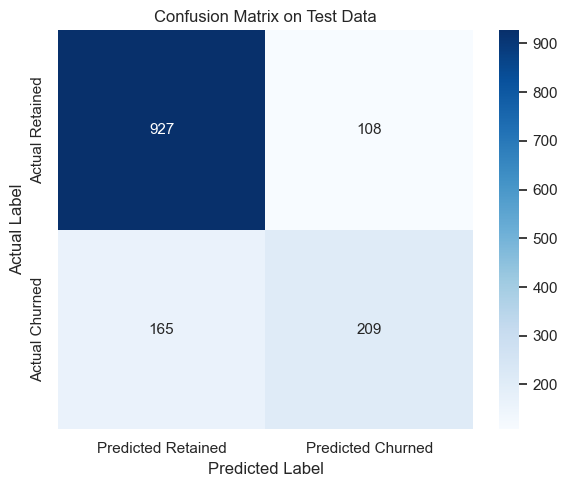

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actual Retained', 'Actual Churned'])
plt.title('Confusion Matrix on Test Data')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_churn.png', dpi=150)
plt.show()

#### B. ROC Curve
The Receiver Operating Characteristic (ROC) curve visualizes the trade-off between the True Positive Rate (Recall) and False Positive Rate across all classification probability thresholds. Our ROC-AUC is **84.22%**, which shows that the model has very strong overall predictive capability.

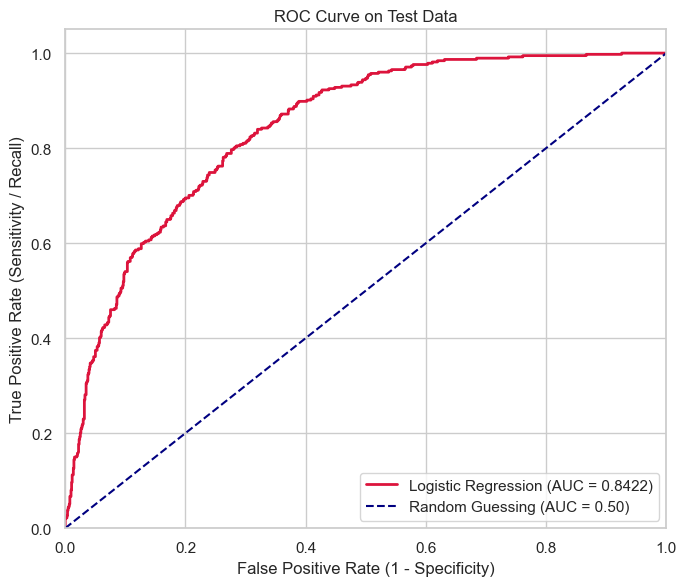

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guessing (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve on Test Data')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_curve_churn.png', dpi=150)
plt.show()

#### C. Model Coefficients (Feature Impact)
Let's extract the trained weights from our model. Sorting these coefficients highlights what factors drive customer retention vs customer churn.

C:\Rtemp\ipykernel_23116\688633363.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coefs, y='Feature', x='Coefficient', palette='coolwarm')


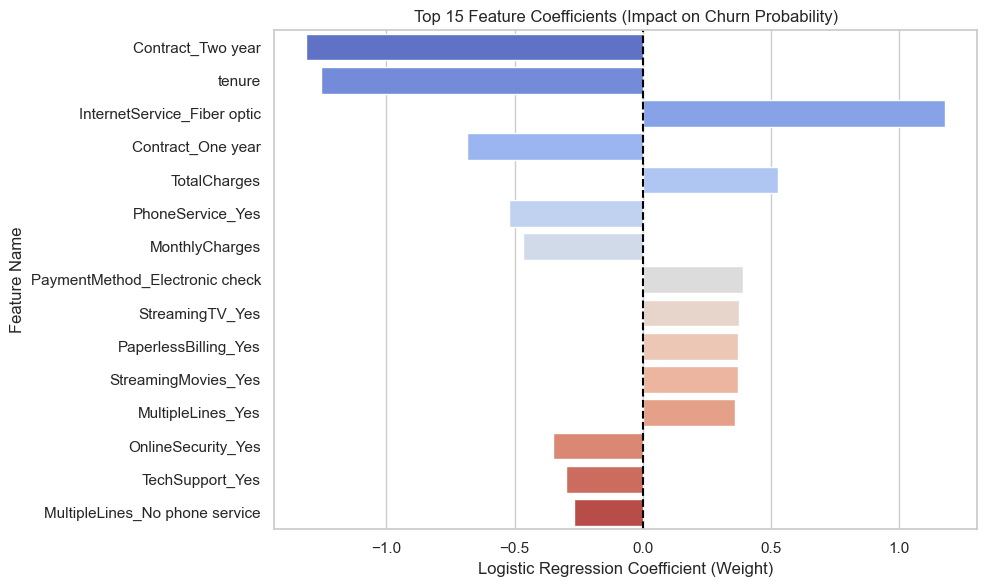

In [14]:
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': churn_model.coef_[0]
})

# Order features by their absolute coefficient value
coefficients['Abs_Weight'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Weight', ascending=False).reset_index(drop=True)

# Select top 15 features for clean visualization
top_coefs = coefficients.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_coefs, y='Feature', x='Coefficient', palette='coolwarm')
plt.title('Top 15 Feature Coefficients (Impact on Churn Probability)')
plt.xlabel('Logistic Regression Coefficient (Weight)')
plt.ylabel('Feature Name')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig('feature_coefficients_churn.png', dpi=150)
plt.show()

### 9. Export Predictions for Downstream Retention Marketing

Finally, we map our test set partition back to its original raw values, and attach our actual ground truth labels, predictions, and churn probabilities to output to a CSV file. Retention teams use this data to target individual at-risk accounts!

In [15]:
# Filter raw dataframe to match test indices
predictions_export = df.loc[X_test.index].copy()
predictions_export['Actual_Churn'] = y_test
predictions_export['Predicted_Churn'] = y_pred
predictions_export['Churn_Probability'] = y_prob

# Write to CSV
predictions_export.to_csv('predictions_churn.csv', index=False)
print(f"Successfully exported {predictions_export.shape[0]} customer predictions to predictions_churn.csv!")

Successfully exported 1409 customer predictions to predictions_churn.csv!


---

## 🎓 Student Analysis & Day 15 Reflection

Today's project was an incredible deep-dive into binary classification! Here are my key data science takeaways and reflections:

### 1. Data Cleaning Gotchas
- Cleaning the `TotalCharges` column was a perfect lesson in real-world data issues. Because blank spaces were represented as text strings, Pandas loaded the column as an object. 
- Figuring out that `tenure = 0` was the root cause of these blank strings let me clean it systematically without dropping rows or introducing bias. Replacing it with `0.0` was the most logical choice.

### 2. Interpreting Feature Coefficients
Looking at the coefficient bar chart, we can extract extremely clear business insights:
- **Strong Churn Drivers (Positive Weights)**:
  - `Contract_Month-to-month` is the single strongest churn driver. This makes sense: month-to-month contracts allow customers to leave effortlessly at any time.
  - `InternetService_Fiber optic` also has a positive coefficient, suggesting Fiber Optic subscribers are unexpectedly at higher risk. This could point to issues like price hikes or customer satisfaction issues with fiber services.
- **Strong Retention Drivers (Negative Weights)**:
  - `tenure` is highly negative. The longer a customer stays, the less likely they are to leave.
  - `Contract_Two year` and `Contract_One year` are powerful retention drivers, demonstrating the high impact of long-term contract lock-in on reducing churn.

### 3. Asymmetric Business Costs of Errors (FP vs. FN)
In binary classification, we can't just look at Accuracy (80.62%). We must analyze our model's errors in detail:
- **False Negatives (FN = 165 cases)**:
  - *What it means*: The model predicts a customer *will not* churn, but they do.
  - *Business Cost*: Extremely high! The company does not target them, and the customer cancels their subscription. If a customer's lifetime value (CLV) is estimated at **$800**, this represents a massive **lost revenue of $800** per customer.
- **False Positives (FP = 108 cases)**:
  - *What it means*: The model predicts a customer *will* churn, but they actually planned to stay.
  - *Business Cost*: Low. The marketing team sends a proactive retention campaign (e.g., a **$50** promo voucher or discount). We spend $50 on a customer who was already staying. This causes slight margin erosion, but it builds customer goodwill.

### Conclusion:
Because a False Negative (**$800** loss) is **16x more costly** than a False Positive (**$50** cost), **Recall (55.88%)** is far more critical to optimize than Precision (65.93%). If we lower our probability threshold below 0.50, we will flag more False Positives, but we will catch far more actual churners, saving the company massive amounts of money! I look forward to exploring how to optimize these thresholds in future days!